In [ ]:
!pip install -q "datasets<3.0" --upgrade #zbog xlm roberta
!pip install -q simpletransformers scikit-learn seaborn

In [ ]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, accuracy_score
from simpletransformers.classification import ClassificationModel
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving opj_dataset.json to opj_dataset (2).json


BRISANJE DUPLIKATA - duplikati sa razlicitim sentimentom su rucno uklonjeni

In [ ]:
DATA_PATH_TMP = "opj_dataset.json"
DATA_PATH = "opj_dataset_no_duplicates.json"

with open(DATA_PATH_TMP, "r", encoding="utf-8") as f:
    data = json.load(f)

seen = set()
unique_data = []

for item in data:
    text = item["tekst"]

    if text not in seen:
        seen.add(text)
        unique_data.append(item)

print("Broj unosa nakon uklanjanja duplikata:", len(unique_data))
print("Uklonjeno duplikata:", len(data) - len(unique_data)) #ocekivano 10

with open(DATA_PATH, "w", encoding="utf-8") as f:
    json.dump(unique_data, f, ensure_ascii=False, indent=2)

Broj unosa nakon uklanjanja duplikata: 2908
Uklonjeno duplikata: 10


UCITAVANJE DATASETA

In [ ]:
LABEL2ID = {"negative": 0, "neutral": 1, "positive": 2}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}

def load_data(path):
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)
    texts, labels = [], []
    for i, item in enumerate(data):
        if item["sentiment"] not in LABEL2ID:
            raise ValueError(f"Nepoznat sentiment na indeksu {i}: {item['sentiment']}")
        texts.append(item["tekst"])
        labels.append(LABEL2ID[item["sentiment"]])
    return np.array(texts, dtype=object), np.array(labels)

X, y = load_data(DATA_PATH)
print(f"Ukupno primera: {len(X)}")

unique, counts = np.unique(y, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {ID2LABEL[u]}: {c}")

Ukupno primera: 2908
  negative: 960
  neutral: 996
  positive: 952


PODESAVANJA

In [ ]:
DATA_PATH = "dataset.json"
LABEL2ID = {"negative": 0, "neutral": 1, "positive": 2}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}

FOLDS_NUM = 10
EPOCHS_NUM = 5
BATCH_SIZE = 16
MAX_LENGTH = 128 # maksimalna duzina sekvence za tokenizator
SEED = 42

is_cuda =  torch.cuda.is_available()
print("Uredjaj:", "cuda" if is_cuda else "cpu")

np.random.seed(SEED)

Uredjaj: cuda


PARAMETRI

In [ ]:
parameter_dict = {
    "num_train_epochs": EPOCHS_NUM,
    "train_batch_size": BATCH_SIZE,
    "eval_batch_size": BATCH_SIZE * 2,
    "max_seq_length": MAX_LENGTH,
    "manual_seed": SEED,
    "learning_rate": 2e-5,
    "overwrite_output_dir": True,
    "save_eval_checkpoints": False,
    "save_model_every_epoch": False,
    "silent": True,
    "no_save": True,
    "fp16": is_cuda,
}

TRENING FOLDA

In [ ]:
#da bi se pamtili rezultati za svaku epohu
parameter_dict_epoch = dict(parameter_dict)
parameter_dict_epoch["num_train_epochs"] = 1

In [ ]:
def train_eval_fold_per_epochs(model_type, model_name, X_tr, y_tr, X_te, y_te, epochs=EPOCHS_NUM):
    train_df = pd.DataFrame(list(zip(X_tr, y_tr)), columns=["text", "labels"])
    eval_df = pd.DataFrame(list(zip(X_te, y_te)), columns=["text", "labels"])

    model = ClassificationModel(
        model_type, model_name,
        num_labels=len(LABEL2ID),
        use_cuda=is_cuda,
        args=parameter_dict_epoch,
    )

    per_epoch_f1 = []
    per_epoch_preds = []

    for epoch in range(1, epochs + 1):
        model.train_model(train_df, show_running_loss=False)

        result, model_outputs, wrong_predictions = model.eval_model(eval_df)
        preds = np.argmax(model_outputs, axis=1)

        f1_epoch = f1_score(y_te, preds, average="macro", zero_division=0)
        per_epoch_f1.append(f1_epoch)
        per_epoch_preds.append(preds)
        print(f"    epoha {epoch}/{epochs}: F1_macro = {f1_epoch:.4f}")

    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return per_epoch_f1, per_epoch_preds

TRENING MODELA

In [ ]:
model_results = {}
labels_order = list(LABEL2ID.keys())


MODEL: xlm-roberta-base (xlmroberta)

Fold 1/10


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.12/dist-packages/simpletransformers/classification/classification_model

Map:   0%|          | 0/2617 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/simpletransformers/classification/classification_utils.py:344: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels = torch.tensor(labels, dtype=torch.long)
/usr/local/lib/python3.12/dist-packages/simpletransformers/classification/classification_model.py:924: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = amp.GradScaler()
/usr/local/lib/python3.12/dist-packages/simpletransformers/classification/classification_model.py:950: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():
/usr/local/lib/python3.12/dist-packages/simpletransformers/classification/classification_model.py:1570: FutureWarning: `torch.cuda.amp.autocast(

...

/usr/local/lib/python3.12/dist-packages/simpletransformers/classification/classification_utils.py:344: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels = torch.tensor(labels, dtype=torch.long)
/usr/local/lib/python3.12/dist-packages/simpletransformers/classification/classification_model.py:924: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = amp.GradScaler()
/usr/local/lib/python3.12/dist-packages/simpletransformers/classification/classification_model.py:950: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():
/usr/local/lib/python3.12/dist-packages/simpletransformers/classification/classification_model.py:1001: UserWarning: Detected call of `lr_schedu

    epoha 4/5: F1_macro = 0.7893


Map:   0%|          | 0/2618 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/simpletransformers/classification/classification_utils.py:344: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels = torch.tensor(labels, dtype=torch.long)
/usr/local/lib/python3.12/dist-packages/simpletransformers/classification/classification_model.py:924: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = amp.GradScaler()
/usr/local/lib/python3.12/dist-packages/simpletransformers/classification/classification_model.py:950: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():
/usr/local/lib/python3.12/dist-packages/simpletransformers/classification/classification_model.py:1001: UserWarning: Detected call of `lr_schedu

    epoha 5/5: F1_macro = 0.7793

Najbolja epoha za xlm-roberta-base: 4 (F1_macro = 0.7813 +/- 0.0138)
              precision    recall  f1-score   support

    negative       0.81      0.85      0.83       960
     neutral       0.78      0.67      0.72       996
    positive       0.75      0.83      0.79       952

    accuracy                           0.78      2908
   macro avg       0.78      0.78      0.78      2908
weighted avg       0.78      0.78      0.78      2908



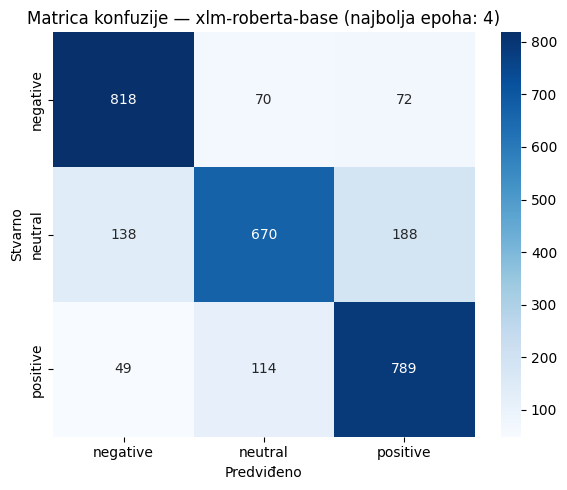

In [ ]:
# xlm roberta nije radio odmah sa SimpleTranformer, pa je izdvojen iz petlje radi testiranja

model_type = "xlmroberta"
model_name = "xlm-roberta-base"

print(f"\n{'='*70}\nMODEL: {model_name} ({model_type})\n{'='*70}")

cv = StratifiedKFold(n_splits=FOLDS_NUM, shuffle=True, random_state=SEED)

fold_f1 = np.zeros((FOLDS_NUM, EPOCHS_NUM))
oof = np.full((EPOCHS_NUM, len(y)), -1, dtype=int)

for fold_idx, (train_index, test_index) in enumerate(cv.split(X, y), start=1):
    print(f"\nFold {fold_idx}/{FOLDS_NUM}")
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    f1s, preds_per_epoch = train_eval_fold_per_epochs(
        model_type, model_name, X_train, y_train, X_test, y_test, epochs=EPOCHS_NUM
    )
    fold_f1[fold_idx - 1] = f1s
    for e in range(EPOCHS_NUM):
        oof[e, test_index] = preds_per_epoch[e]

mean_f1 = fold_f1.mean(axis=0)
std_f1 = fold_f1.std(axis=0)
best_epoch = int(np.argmax(mean_f1)) + 1
oof_best = oof[best_epoch - 1]

print(f"\nNajbolja epoha za {model_name}: {best_epoch} "
      f"(F1_macro = {mean_f1[best_epoch - 1]:.4f} +/- {std_f1[best_epoch - 1]:.4f})")

# klasifikacioni izvestaj i matrica konfuzije
print(classification_report(y, oof_best, target_names=labels_order, zero_division=0))

cm = confusion_matrix(y, oof_best)
naziv_kratak = model_name.split("/")[-1]

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels_order, yticklabels=labels_order)
plt.xlabel("Predviđeno")
plt.ylabel("Stvarno")
plt.title(f"Matrica konfuzije — {naziv_kratak} (najbolja epoha: {best_epoch})")
plt.tight_layout()
plt.savefig(f"confusion_matrix_{naziv_kratak}_epoha{best_epoch}.png", dpi=150)
plt.show()

model_results[model_name] = {
    "mean_f1": mean_f1,
    "std_f1": std_f1,
    "fold_f1": fold_f1,
    "best_epoch": best_epoch,
    "oof": oof,
    "oof_best": oof_best,
    "confusion_matrix": cm,
}

In [ ]:
MODELS = [
    ("electra", "classla/bcms-bertic"),
    ("bert", "bert-base-multilingual-cased"),
    #("xlmroberta", "xlm-roberta-base"),
]


MODEL: classla/bcms-bertic (electra)

Fold 1/10


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] ElectraForSequenceClassification LOAD REPORT from: classla/bcms-bertic
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
classifier.dense.bias                             | MISSING    | 
classifier.dense.weight                           | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/l

    epoha 1/5: F1_macro = 0.7255


/usr/local/lib/python3.12/dist-packages/simpletransformers/classification/classification_model.py:924: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = amp.GradScaler()
/usr/local/lib/python3.12/dist-packages/simpletransformers/classification/classification_model.py:950: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():
/usr/local/lib/python3.12/dist-packages/simpletransformers/classification/classification_model.py:1570: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():


...

    epoha 3/5: F1_macro = 0.8076


/usr/local/lib/python3.12/dist-packages/simpletransformers/classification/classification_model.py:924: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = amp.GradScaler()
/usr/local/lib/python3.12/dist-packages/simpletransformers/classification/classification_model.py:950: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():
/usr/local/lib/python3.12/dist-packages/simpletransformers/classification/classification_model.py:1570: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():


    epoha 4/5: F1_macro = 0.7947


/usr/local/lib/python3.12/dist-packages/simpletransformers/classification/classification_model.py:924: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = amp.GradScaler()
/usr/local/lib/python3.12/dist-packages/simpletransformers/classification/classification_model.py:950: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():
/usr/local/lib/python3.12/dist-packages/simpletransformers/classification/classification_model.py:1570: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():


    epoha 5/5: F1_macro = 0.7978

Najbolja epoha za classla/bcms-bertic: 4 (F1_macro = 0.8211 +/- 0.0217)
              precision    recall  f1-score   support

    negative       0.86      0.89      0.88       960
     neutral       0.79      0.74      0.77       996
    positive       0.81      0.84      0.82       952

    accuracy                           0.82      2908
   macro avg       0.82      0.82      0.82      2908
weighted avg       0.82      0.82      0.82      2908



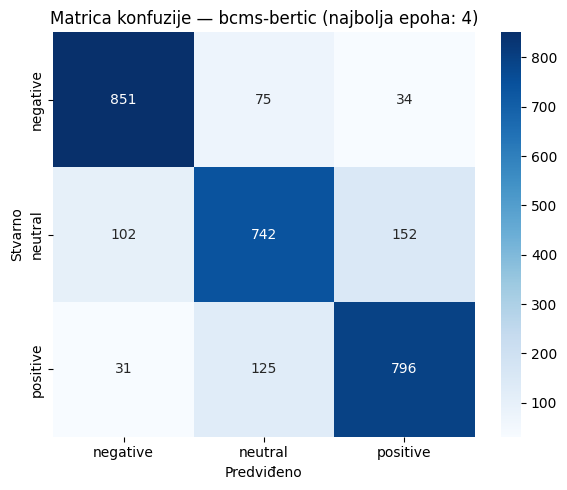


MODEL: bert-base-multilingual-cased (bert)

Fold 1/10


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/

    epoha 1/5: F1_macro = 0.6286


/usr/local/lib/python3.12/dist-packages/simpletransformers/classification/classification_model.py:924: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = amp.GradScaler()
/usr/local/lib/python3.12/dist-packages/simpletransformers/classification/classification_model.py:950: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():
/usr/local/lib/python3.12/dist-packages/simpletransformers/classification/classification_model.py:1570: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():


...

    epoha 3/5: F1_macro = 0.6579


/usr/local/lib/python3.12/dist-packages/simpletransformers/classification/classification_model.py:924: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = amp.GradScaler()
/usr/local/lib/python3.12/dist-packages/simpletransformers/classification/classification_model.py:950: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():
/usr/local/lib/python3.12/dist-packages/simpletransformers/classification/classification_model.py:1570: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():


    epoha 4/5: F1_macro = 0.6402


/usr/local/lib/python3.12/dist-packages/simpletransformers/classification/classification_model.py:924: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = amp.GradScaler()
/usr/local/lib/python3.12/dist-packages/simpletransformers/classification/classification_model.py:950: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():
/usr/local/lib/python3.12/dist-packages/simpletransformers/classification/classification_model.py:1570: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():


    epoha 5/5: F1_macro = 0.6586

Najbolja epoha za bert-base-multilingual-cased: 5 (F1_macro = 0.7084 +/- 0.0272)
              precision    recall  f1-score   support

    negative       0.71      0.75      0.73       960
     neutral       0.73      0.68      0.70       996
    positive       0.68      0.70      0.69       952

    accuracy                           0.71      2908
   macro avg       0.71      0.71      0.71      2908
weighted avg       0.71      0.71      0.71      2908



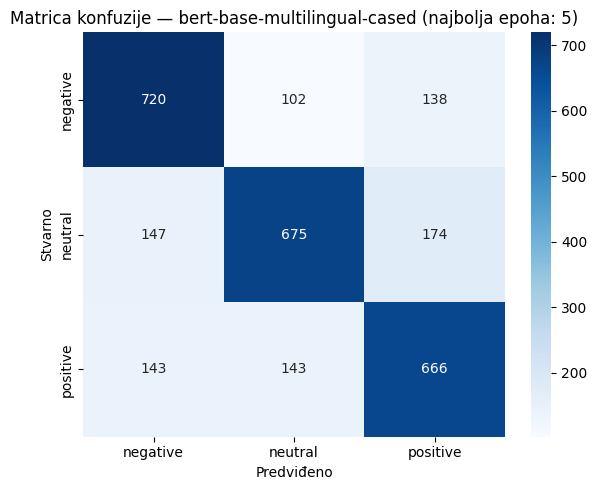

In [ ]:
for model_type, model_name in MODELS:
    print(f"\n{'='*70}\nMODEL: {model_name} ({model_type})\n{'='*70}")

    cv = StratifiedKFold(n_splits=FOLDS_NUM, shuffle=True, random_state=SEED)

    fold_f1 = np.zeros((FOLDS_NUM, EPOCHS_NUM))
    oof = np.full((EPOCHS_NUM, len(y)), -1, dtype=int)

    for fold_idx, (train_index, test_index) in enumerate(cv.split(X, y), start=1):
        print(f"\nFold {fold_idx}/{FOLDS_NUM}")
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]

        f1s, preds_per_epoch = train_eval_fold_per_epochs(
            model_type, model_name, X_train, y_train, X_test, y_test, epochs=EPOCHS_NUM
        )
        fold_f1[fold_idx - 1] = f1s
        for e in range(EPOCHS_NUM):
            oof[e, test_index] = preds_per_epoch[e]

    mean_f1 = fold_f1.mean(axis=0)
    std_f1 = fold_f1.std(axis=0)
    best_epoch = int(np.argmax(mean_f1)) + 1
    oof_best = oof[best_epoch - 1]

    print(f"\nNajbolja epoha za {model_name}: {best_epoch} "
          f"(F1_macro = {mean_f1[best_epoch - 1]:.4f} +/- {std_f1[best_epoch - 1]:.4f})")

    # klasifikacioni izvestaj i matrica konfuzije
    print(classification_report(y, oof_best, target_names=labels_order, zero_division=0))

    cm = confusion_matrix(y, oof_best)
    naziv_kratak = model_name.split("/")[-1]

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels_order, yticklabels=labels_order)
    plt.xlabel("Predviđeno")
    plt.ylabel("Stvarno")
    plt.title(f"Matrica konfuzije — {naziv_kratak} (najbolja epoha: {best_epoch})")
    plt.tight_layout()
    plt.savefig(f"confusion_matrix_{naziv_kratak}_epoha{best_epoch}.png", dpi=150)
    plt.show()

    model_results[model_name] = {
        "mean_f1": mean_f1,
        "std_f1": std_f1,
        "fold_f1": fold_f1,
        "best_epoch": best_epoch,
        "oof": oof,
        "oof_best": oof_best,
        "confusion_matrix": cm,
    }

GRAF

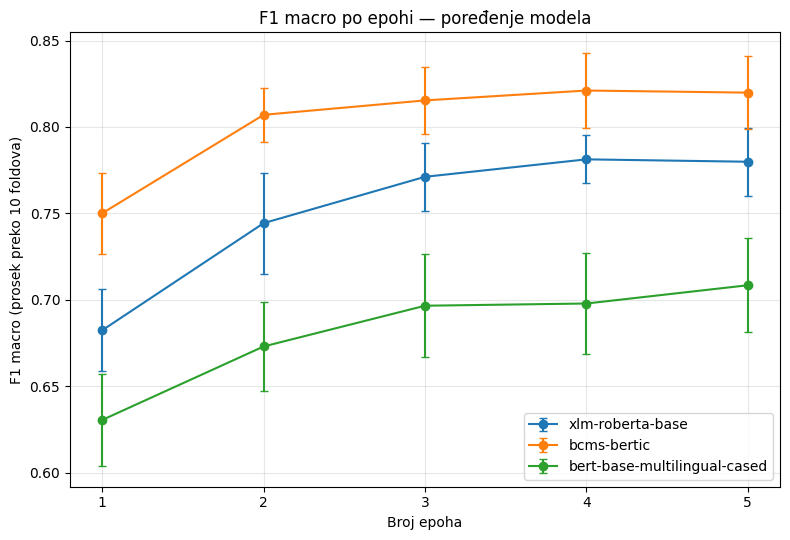

In [ ]:
plt.figure(figsize=(8, 5.5))

colors = plt.cm.tab10.colors

for i, (model_name, rez) in enumerate(model_results.items()):
    mean_f1 = rez["mean_f1"]
    std_f1 = rez["std_f1"]
    epochs_x = np.arange(1, len(mean_f1) + 1)

    plt.errorbar(
        epochs_x, mean_f1, yerr=std_f1,
        marker="o", capsize=3, color=colors[i % len(colors)],
        label=model_name.split("/")[-1],
    )

plt.xlabel("Broj epoha")
plt.ylabel("F1 macro (prosek preko 10 foldova)")
plt.title("F1 macro po epohi — poređenje modela")
plt.xticks(np.arange(1, EPOCHS_NUM + 1))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("kriva_epoha_svi_modeli.png", dpi=150)
plt.show()